# Heat Kernel Attention: Scaling Experiments (v3)

**Paper:** Diffusion Attention: Replacing Softmax with Heat Kernel Dynamics  
**Author:** Joshua D. Curry  
**Repo:** https://github.com/JDCurry/Heat-Kernel-Attention  

**Compute budget:** ~92 CU (Colab Pro for Education)  
**Execution order:** Track 2 (constraint sweep) → Track 1 (seq length) → Track 3 (A100 validation)

---


## 0. Environment Setup

In [ ]:
# ── Check GPU and estimate CU burn rate ──
import torch
import subprocess, os

gpu_name = "CPU"
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    bf16 = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name}")
    print(f"VRAM: {vram_gb:.1f} GB")
    print(f"bfloat16: {bf16}")
    print(f"CUDA: {torch.version.cuda}")

    # Estimate CU burn rate
    if "T4" in gpu_name:
        print(f"\nEstimated burn: ~1.76 CU/hr (budget: ~52 hrs)")
    elif "A100" in gpu_name:
        print(f"\nEstimated burn: ~15 CU/hr (budget: ~6 hrs)")
    elif "L4" in gpu_name:
        print(f"\nEstimated burn: ~4.5 CU/hr (budget: ~20 hrs)")
    else:
        print(f"\nUnknown GPU tier -- monitor CU usage manually")
else:
    print("WARNING: No GPU detected! Go to Runtime > Change runtime type > GPU")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
bfloat16: True
CUDA: 12.8

Estimated burn: ~15 CU/hr (budget: ~6 hrs)


In [ ]:
# ── Clone repo and install dependencies ──
import os, sys

if not os.path.exists("/content/Heat-Kernel-Attention"):
    !git clone https://github.com/JDCurry/Heat-Kernel-Attention.git /content/Heat-Kernel-Attention

# The v2 code lives under extended_validation_2026/
# train.py imports from src.model, src.data, src.loss which are all here
REPO_ROOT = "/content/Heat-Kernel-Attention"
EV_ROOT = os.path.join(REPO_ROOT, "extended_validation_2026")
os.chdir(EV_ROOT)
sys.path.insert(0, EV_ROOT)

print(f"Working dir: {os.getcwd()}")
print(f"Contents:")
!ls -la

# Install requirements
if os.path.exists(os.path.join(REPO_ROOT, "requirements.txt")):
    !pip install -r {REPO_ROOT}/requirements.txt -q
!pip install tiktoken datasets tqdm numpy -q

# Verify imports work
from src.model.transformer import ModelConfig, DiffusionNativeTransformer
from src.data.dataset import create_dataloaders
print("\nAll imports OK")


Cloning into '/content/Heat-Kernel-Attention'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 111 (delta 27), reused 106 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 851.63 KiB | 28.39 MiB/s, done.
Resolving deltas: 100% (27/27), done.
Working dir: /content/Heat-Kernel-Attention/extended_validation_2026
Contents:
total 20
drwxr-xr-x  5 root root 4096 Apr 30 19:24 .
drwxr-xr-x  6 root root 4096 Apr 30 19:24 ..
drwxr-xr-x 14 root root 4096 Apr 30 19:24 results
drwxr-xr-x  2 root root 4096 Apr 30 19:24 scripts
drwxr-xr-x  8 root root 4096 Apr 30 19:24 src

All imports OK


In [ ]:
# ── Mount Google Drive for checkpoint persistence ──
from google.colab import drive
drive.mount('/content/drive')

# Create results directory on Drive
DRIVE_RESULTS = "/content/drive/MyDrive/hka_scaling_v3"
os.makedirs(DRIVE_RESULTS, exist_ok=True)
print(f"Results will save to: {DRIVE_RESULTS}")

Mounted at /content/drive
Results will save to: /content/drive/MyDrive/hka_scaling_v3


In [ ]:
# ── Pin tiktoken download (avoid mid-training network issues) ──
import tiktoken
enc = tiktoken.get_encoding("gpt2")
print(f"Tokenizer loaded: {enc.name}, vocab size: {enc.n_vocab}")


Tokenizer loaded: gpt2, vocab size: 50257


## Shared: Training Utilities

In [ ]:
import math, json, time, csv, shutil
from pathlib import Path
from dataclasses import asdict

import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from tqdm.notebook import tqdm  # notebook-friendly progress bars

from src.model.transformer import ModelConfig, DiffusionNativeTransformer
from src.data.dataset import create_dataloaders


def get_seq_len_run_config(attention_mode, n_layers=12):
    """Config for sequence length scaling runs (Track 1)."""
    t_base = 0.28
    L_base = 4
    t_center = t_base * math.sqrt(L_base / n_layers)

    if attention_mode == "softmax":
        return {
            "attention_mode": "softmax",
            "training_mode": "standard",
            "alpha": 0.0,
            "description": "Softmax baseline",
        }
    elif attention_mode == "diffusion_fixed":
        return {
            "attention_mode": "diffusion_fixed",
            "training_mode": "standard",
            "fixed_t": t_center,
            "alpha": 0.0,
            "description": f"Diffusion (fixed t={t_center:.4f})",
        }
    else:
        raise ValueError(f"Unknown mode: {attention_mode}")


def get_constraint_run_config(constraint_pct, n_layers=12):
    """Config for constraint width sweep runs (Track 2)."""
    t_base = 0.28
    L_base = 4
    t_center = t_base * math.sqrt(L_base / n_layers)

    if constraint_pct is None:
        # Unconstrained (A3 replication)
        return {
            "attention_mode": "diffusion_learned",
            "training_mode": "standard",
            "fixed_t": t_center,
            "t_min": 0.01,
            "t_max": 5.0,
            "alpha": 0.0,
            "description": f"Unconstrained learned t",
        }
    else:
        frac = constraint_pct / 100.0
        calculated_t_min = t_center * (1.0 - frac)

        # Robustly handle cases where calculated_t_min might be zero due to floating point arithmetic
        if abs(calculated_t_min) < 1e-7: # Check if it's effectively zero
            min_t_val = 1e-5
        else:
            min_t_val = max(1e-6, calculated_t_min)
        max_t_val = t_center * (1.0 + frac)
        return {
            "attention_mode": "diffusion_learned",
            "training_mode": "standard",
            "fixed_t": t_center,
            "t_min": min_t_val,
            "t_max": max_t_val,
            "alpha": 0.0,
            "description": f"Constrained t \u00B1{constraint_pct}% [{min_t_val:.4f}, {max_t_val:.4f}]",
        }


def evaluate(model, val_loader, device, use_amp, amp_dtype, max_batches=50):
    """Streaming evaluation (from train.py, unchanged)."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    total_confidence = 0.0
    total_correct = 0.0
    total_brier = 0.0
    n_bins = 15
    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    bin_counts = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sums = np.zeros(n_bins, dtype=np.float64)
    bin_correct_sums = np.zeros(n_bins, dtype=np.float64)

    with torch.no_grad():
        for i, (x, y) in enumerate(val_loader):
            if i >= max_batches:
                break
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
                output = model(x)
                logits = output["logits"]
            logits_flat = logits.view(-1, logits.size(-1)).float().cpu()
            targets_flat = y.view(-1).cpu()
            batch_loss = F.cross_entropy(logits_flat, targets_flat, reduction="sum")
            total_loss += batch_loss.item()
            probs = F.softmax(logits_flat, dim=-1)
            confidences, predictions = probs.max(dim=-1)
            correct = (predictions == targets_flat).float()
            total_tokens += targets_flat.numel()
            total_confidence += confidences.sum().item()
            total_correct += correct.sum().item()
            total_brier += ((confidences - correct) ** 2).sum().item()
            confidences_np = confidences.detach().cpu().numpy()
            correct_np = correct.detach().cpu().numpy()
            bin_indices = np.digitize(confidences_np, bin_boundaries, right=True) - 1
            bin_indices = np.clip(bin_indices, 0, n_bins - 1)
            for bin_idx in range(n_bins):
                in_bin = bin_indices == bin_idx
                if not np.any(in_bin):
                    continue
                bin_counts[bin_idx] += in_bin.sum()
                bin_conf_sums[bin_idx] += confidences_np[in_bin].sum()
                bin_correct_sums[bin_idx] += correct_np[in_bin].sum()

    if total_tokens == 0:
        return {k: float("nan") for k in
                ["loss", "perplexity", "ece", "brier",
                 "mean_confidence", "mean_accuracy", "overconfidence"]}

    avg_loss = total_loss / total_tokens
    try:
        perplexity = math.exp(min(avg_loss, 20))
    except OverflowError:
        perplexity = float("inf")
    mean_confidence = total_confidence / total_tokens
    mean_accuracy = total_correct / total_tokens
    brier = total_brier / total_tokens
    ece = 0.0
    for bin_idx in range(n_bins):
        if bin_counts[bin_idx] > 0:
            prop_in_bin = bin_counts[bin_idx] / total_tokens
            avg_conf = bin_conf_sums[bin_idx] / bin_counts[bin_idx]
            avg_acc = bin_correct_sums[bin_idx] / bin_counts[bin_idx]
            ece += abs(avg_acc - avg_conf) * prop_in_bin

    model.train()
    return {
        "loss": avg_loss, "perplexity": perplexity, "ece": ece, "brier": brier,
        "mean_confidence": mean_confidence, "mean_accuracy": mean_accuracy,
        "overconfidence": mean_confidence - mean_accuracy,
    }


def train_run(
    run_label,
    run_config,
    dataset="wikitext-103",
    n_layers=12,
    d_model=256,
    n_heads=4,
    d_ff=1024,
    seq_len=256,
    batch_size=32,
    grad_accum=1,
    max_steps=25000,
    lr=3e-4,
    eval_interval=500,
    save_interval=5000,
    seed=42,
    gradient_checkpointing=False,
    drive_dir=DRIVE_RESULTS,
):
    """Train a single run with Drive persistence and CSV logging."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
    torch.backends.cudnn.benchmark = True

    # Set memory config for T4
    if "T4" in torch.cuda.get_device_name(0):
        os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

    print(f"\n{'='*70}")
    print(f"RUN {run_label}: {run_config['description']}")
    print(f"  seq_len={seq_len}, batch={batch_size}x{grad_accum}={batch_size*grad_accum}")
    print(f"  max_steps={max_steps}, dataset={dataset}")
    print(f"{'='*70}")

    model_config = ModelConfig(
        d_model=d_model, n_heads=n_heads, n_layers=n_layers, d_ff=d_ff,
        attention_mode=run_config["attention_mode"],
        fixed_t=run_config.get("fixed_t", 0.16),
        alpha=run_config.get("alpha", 0.0),
        t_min=run_config.get("t_min", 0.05),
        t_max=run_config.get("t_max", 2.0),
        training_mode=run_config.get("training_mode", "standard"),
        max_seq_len=seq_len,
    )

    # Directories
    exp_name = f"{run_label}_{dataset}_seq{seq_len}"
    local_dir = Path(f"./results/{exp_name}")
    local_dir.mkdir(parents=True, exist_ok=True)
    drive_exp_dir = Path(drive_dir) / exp_name
    drive_exp_dir.mkdir(parents=True, exist_ok=True)

    # Save config
    full_config = {
        "run_label": run_label, "run_config": run_config,
        "model_config": asdict(model_config),
        "dataset": dataset, "seq_len": seq_len,
        "batch_size": batch_size, "grad_accum": grad_accum,
        "effective_batch": batch_size * grad_accum,
        "max_steps": max_steps, "lr": lr, "seed": seed,
    }
    with open(drive_exp_dir / "config.json", "w") as f:
        json.dump(full_config, f, indent=2)

    # Data
    data = create_dataloaders(
        variant=dataset, seq_len=seq_len, batch_size=batch_size,
        num_workers=2,  # Colab has limited CPU
    )
    train_loader = data["train"]
    val_loader = data["val"]
    print(f"  Train tokens: {data['train_tokens']:,}")
    print(f"  Steps/epoch: {len(train_loader):,}")

    # Model
    model = DiffusionNativeTransformer(model_config).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    if gradient_checkpointing:
        # model.gradient_checkpointing_enable() # This method is not available for DiffusionNativeTransformer
        print("  Gradient checkpointing: ON (but not enabled for this model type)")

    # Check for resume
    resume_step = 0
    ckpt_path = drive_exp_dir / "latest_checkpoint.pt"
    if ckpt_path.exists():
        print(f"  Resuming from {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        resume_step = ckpt["step"]
        print(f"  Resumed at step {resume_step}")

    # Optimizer, scheduler
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, max_steps)

    if ckpt_path.exists() and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        for _ in range(resume_step):
            scheduler.step()

    # AMP
    use_amp = torch.cuda.is_available()
    amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))
    print(f"  Precision: {amp_dtype}")

    # CSV logger (append-safe across disconnects)
    csv_path = drive_exp_dir / "metrics.csv"
    csv_exists = csv_path.exists()
    csv_file = open(csv_path, "a", newline="")
    csv_writer = csv.writer(csv_file)
    if not csv_exists:
        csv_writer.writerow([
            "step", "val_loss", "perplexity", "ece", "brier",
            "mean_confidence", "mean_accuracy", "overconfidence",
            "train_loss", "elapsed_min", "tokens_seen"
        ])
        csv_file.flush()

    # t-trajectory log
    t_log_path = drive_exp_dir / "t_trajectories.csv"
    t_exists = t_log_path.exists()
    t_file = open(t_log_path, "a", newline="")
    t_writer = csv.writer(t_file)
    if not t_exists:
        t_headers = ["step"] + [f"layer_{i}" for i in range(n_layers)]
        t_writer.writerow(t_headers)
        t_file.flush()

    # Training loop
    global_step = resume_step
    best_val_loss = float("inf")
    start_time = time.time()
    epoch_loss = 0.0
    epoch_steps = 0

    optimizer.zero_grad(set_to_none=True)

    print(f"\n  Training from step {global_step} to {max_steps}...\n")

    with tqdm(total=max_steps, initial=global_step, desc=f"Training {run_label}") as pbar:
        while global_step < max_steps:
            model.train()
            for batch_idx, (x, y) in enumerate(train_loader):
                if global_step >= max_steps:
                    break

                x = x.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
                    output = model(x)
                    loss = F.cross_entropy(
                        output["logits"].view(-1, output["logits"].size(-1)),
                        y.view(-1)
                    )
                    loss = loss / grad_accum

                if scaler.is_enabled():
                    scaler.scale(loss).backward()
                else:
                    loss.backward()

                if (batch_idx + 1) % grad_accum == 0:
                    if scaler.is_enabled():
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad(set_to_none=True);

                    epoch_loss += loss.item() * grad_accum
                    epoch_steps += 1
                    global_step += 1
                    pbar.update(1)

                    # Track t values
                    if global_step % 100 == 0:
                        t_vals = []
                        for block in model.blocks:
                            t = block.attn.get_t()
                            if isinstance(t, torch.Tensor):
                                if t.numel() > 1:
                                    t_val = t.mean().item()
                                else:
                                    t_val = t.item()
                            else:
                                t_val = t
                            t_vals.append(t_val)
                        t_writer.writerow([global_step] + t_vals)
                        t_file.flush()

                    # Evaluate
                    if global_step % eval_interval == 0:
                        val_metrics = evaluate(model, val_loader, device, use_amp, amp_dtype, max_batches=50)
                        elapsed = time.time() - start_time
                        tokens_seen = global_step * batch_size * seq_len * grad_accum
                        train_loss_avg = epoch_loss / max(epoch_steps, 1)

                        csv_writer.writerow([
                            global_step, val_metrics["loss"], val_metrics["perplexity"],
                            val_metrics["ece"], val_metrics["brier"],
                            val_metrics["mean_confidence"], val_metrics["mean_accuracy"],
                            val_metrics["overconfidence"],
                            train_loss_avg, elapsed / 60, tokens_seen,
                        ])
                        csv_file.flush()

                        if val_metrics["loss"] < best_val_loss:
                            best_val_loss = val_metrics["loss"]
                            torch.save({
                                "model_state_dict": model.state_dict(),
                                "config": asdict(model_config),
                                "step": global_step,
                                "val_metrics": val_metrics,
                            }, drive_exp_dir / "best_model.pt")

                    # Save checkpoint for resume
                    if global_step % save_interval == 0:
                        torch.save({
                            "model_state_dict": model.state_dict(),
                            "optimizer_state_dict": optimizer.state_dict(),
                            "step": global_step,
                            "config": asdict(model_config),
                        }, drive_exp_dir / "latest_checkpoint.pt")
                        print(f"  [Checkpoint saved at step {global_step}]")

    csv_file.close()
    t_file.close()

    elapsed = time.time() - start_time
    print(f"\n{'='*70}")
    print(f"COMPLETE: {run_label}")
    print(f"  Best val loss: {best_val_loss:.4f}, PPL: {math.exp(min(best_val_loss, 20)):.1f}")
    print(f"  Total time: {elapsed/60:.1f} min")
    print(f"  Results: {drive_exp_dir}")
    print(f"{'='*70}")

    return {"run": run_label, "best_val_loss": best_val_loss, "steps": global_step}

print("Training utilities loaded.")

Training utilities loaded.


---

## Track 2: Constraint Width Sweep (~4.2 CU, ~2.5 hrs on T4)

**Run this first.** Cheapest, fastest, produces two figures for the paper.

**Question:** Is ±50% the optimal constraint window?

Runs on WikiText-2 at seq_len=256 with 10K steps each. Traces the learned-t trajectory and maps the PPL/ECE Pareto frontier as a function of constraint width.


In [ ]:
# ── Track 2: Run constraint sweep ──
from tqdm.notebook import tqdm

# Original list of constraint widths
all_constraint_widths = [20, 30, 50, 75, 100, None]

# Retrieve existing results from kernel state to append to, or initialize if not present
# This assumes 'track2_results' might exist from previous partial runs
if 'track2_results' not in globals():
    track2_results = []

# Identify completed runs from the existing track2_results
completed_labels = {r['run'] for r in track2_results}

# Filter out widths that have already been completed
remaining_constraint_widths = []
for cw in all_constraint_widths:
    label = f"C_pct{cw}" if cw is not None else "C_unconstrained"
    if label not in completed_labels:
        remaining_constraint_widths.append(cw)

print(f"Resuming Track 2. Completed runs: {sorted(list(completed_labels))}")
print(f"Remaining runs to execute: {remaining_constraint_widths}")

for cw in tqdm(remaining_constraint_widths, desc="Running Constraint Sweep (Resumed)"):
    label = f"C_pct{cw}" if cw is not None else "C_unconstrained"
    config = get_constraint_run_config(cw)

    result = train_run(
        run_label=label,
        run_config=config,
        dataset="wikitext-2",
        seq_len=256,
        batch_size=32,
        grad_accum=1,
        max_steps=10000,
        eval_interval=500,
        save_interval=10000,  # only save at end
    )
    track2_results.append(result)
    print(f"\n  >> {label} done: best_val_loss={result['best_val_loss']:.4f}\n")

print("\n=== Track 2 Complete ===")
for r in track2_results:
    print(f"  {r['run']}: val_loss={r['best_val_loss']:.4f}, ppl={math.exp(min(r['best_val_loss'],20)):.1f}")

Resuming Track 2. Completed runs: ['C_pct20', 'C_pct30', 'C_pct50', 'C_pct75']
Remaining runs to execute: [100, None]


Running Constraint Sweep (Resumed):   0%|          | 0/2 [00:00<?, ?it/s]


RUN C_pct100: Constrained t ±100% [0.0000, 0.3233]
  seq_len=256, batch=32x1=32
  max_steps=10000, dataset=wikitext-2
  Loading cached tokens from token_cache/wikitext-2_train_all.pt
  Loading cached tokens from token_cache/wikitext-2_validation_all.pt
  Loading cached tokens from token_cache/wikitext-2_test_all.pt
  Train tokens: 2,347,038
  Steps/epoch: 73,337
Model: 12L, d=256, diffusion_learned, t_center=0.1617
  Parameters: 22,396,720
  Training mode: standard
  Parameters: 22,396,720
  Precision: torch.bfloat16

  Training from step 0 to 10000...



/tmp/ipykernel_13212/816222414.py:265: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))
/tmp/ipykernel_13212/816222414.py:311: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
/tmp/ipykernel_13212/816222414.py:105: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


  Step 500/10,000: ppl=516.0, ECE=0.0274, brier=0.1214 in, 4M tok]
  Step 1,000/10,000: ppl=313.8, ECE=0.0400, brier=0.1343 in, 8M tok]
  Step 1,500/10,000: ppl=220.4, ECE=0.0243, brier=0.1379 in, 12M tok]
  Step 2,000/10,000: ppl=165.4, ECE=0.0232, brier=0.1438 in, 16M tok]
  Step 2,500/10,000: ppl=146.8, ECE=0.0321, brier=0.1480 in, 20M tok]
  Step 3,000/10,000: ppl=124.9, ECE=0.0106, brier=0.1420 in, 25M tok]
  Step 3,500/10,000: ppl=108.6, ECE=0.0121, brier=0.1445 in, 29M tok]
  Step 4,000/10,000: ppl=103.4, ECE=0.0185, brier=0.1504 in, 33M tok]
  Step 4,500/10,000: ppl=104.0, ECE=0.0204, brier=0.1472 in, 37M tok]
  Step 5,000/10,000: ppl=95.3, ECE=0.0221, brier=0.1509 in, 41M tok]
  Step 5,500/10,000: ppl=95.0, ECE=0.0231, brier=0.1517 in, 45M tok]
  Step 6,000/10,000: ppl=95.5, ECE=0.0286, brier=0.1512 in, 49M tok]
  Step 6,500/10,000: ppl=96.7, ECE=0.0327, brier=0.1548 in, 53M tok]
  Step 7,000/10,000: ppl=97.1, ECE=0.0339, brier=0.1509 in, 57M tok]
  Step 7,500/10,000: ppl=95.7

### Track 2: Visualization

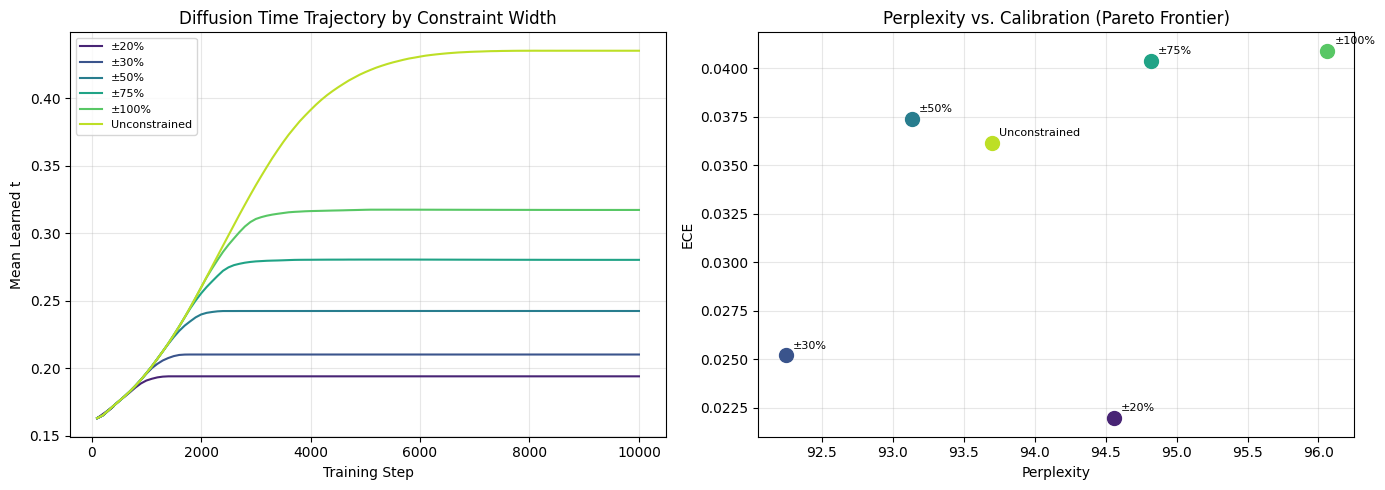

Figure saved to /content/drive/MyDrive/hka_scaling_v3/track2_constraint_sweep.png


In [ ]:
# ── Track 2: Plot Pareto frontier and t-trajectories ──
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: t-trajectory overlay ──
ax1 = axes[0]
constraint_labels = ["±20%", "±30%", "±50%", "±75%", "±100%", "Unconstrained"]
constraint_dirs = ["C_pct20", "C_pct30", "C_pct50", "C_pct75", "C_pct100", "C_unconstrained"]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(constraint_dirs)))

for label, dirname, color in zip(constraint_labels, constraint_dirs, colors):
    t_path = Path(DRIVE_RESULTS) / f"{dirname}_wikitext-2_seq256" / "t_trajectories.csv"
    if t_path.exists():
        df = pd.read_csv(t_path)
        # Plot mean t across layers
        t_cols = [c for c in df.columns if c.startswith("layer_")]
        df["mean_t"] = df[t_cols].mean(axis=1)
        ax1.plot(df["step"], df["mean_t"], label=label, color=color, linewidth=1.5)

ax1.set_xlabel("Training Step")
ax1.set_ylabel("Mean Learned t")
ax1.set_title("Diffusion Time Trajectory by Constraint Width")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Right: PPL vs ECE Pareto ──
ax2 = axes[1]
for label, dirname, color in zip(constraint_labels, constraint_dirs, colors):
    csv_path = Path(DRIVE_RESULTS) / f"{dirname}_wikitext-2_seq256" / "metrics.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        # Use final row
        final = df.iloc[-1]
        ax2.scatter(final["perplexity"], final["ece"], color=color, s=100, zorder=5)
        ax2.annotate(label, (final["perplexity"], final["ece"]),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)

ax2.set_xlabel("Perplexity")
ax2.set_ylabel("ECE")
ax2.set_title("Perplexity vs. Calibration (Pareto Frontier)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(DRIVE_RESULTS) / "track2_constraint_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {DRIVE_RESULTS}/track2_constraint_sweep.png")


---

## Track 1: Sequence Length Scaling (~57 CU, ~32 hrs on T4)

**Question:** Does the calibration advantage grow with context length?

Runs paired softmax/diffusion comparisons at 512, 1024, and 2048 tokens on WikiText-103.

**Important:** Run these in order (512 first). If you run out of CU or hit OOM at 2048, you still have usable results from the shorter runs.


In [ ]:
# ── Track 1 VRAM smoke test ──
# Run 100 steps at each seq_len to verify no OOM before committing hours

for test_seq in [512, 1024, 2048]:
    print(f"\n--- Smoke test: seq_len={test_seq} ---")

    # Adjust batch size for VRAM
    if test_seq <= 512:
        bs, ga = 16, 2
    elif test_seq <= 1024:
        bs, ga = 8, 4
    else:
        bs, ga = 4, 8

    gc = test_seq >= 2048  # gradient checkpointing for 2048+

    config = get_seq_len_run_config("diffusion_fixed")
    try:
        result = train_run(
            run_label=f"smoke_seq{test_seq}",
            run_config=config,
            dataset="wikitext-2",  # small dataset for smoke test
            seq_len=test_seq,
            batch_size=bs,
            grad_accum=ga,
            max_steps=100,
            eval_interval=50,
            save_interval=200,
            gradient_checkpointing=gc,
        )
        print(f"  PASS: seq_len={test_seq}, bs={bs}, grad_accum={ga}, gc={gc}")
        torch.cuda.empty_cache()
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"  OOM at seq_len={test_seq}! Reduce batch or skip this length.")
            torch.cuda.empty_cache()
            if test_seq == 2048:
                print("  >> Will fall back to seq_len=1536 for Track 1")
        else:
            raise

print("\nSmoke tests complete. Adjust batch sizes above if any OOM occurred.")



--- Smoke test: seq_len=512 ---

RUN smoke_seq512: Diffusion (fixed t=0.1617)
  seq_len=512, batch=16x2=32
  max_steps=100, dataset=wikitext-2
  Loading cached tokens from token_cache/wikitext-2_train_all.pt
  Loading cached tokens from token_cache/wikitext-2_validation_all.pt
  Loading cached tokens from token_cache/wikitext-2_test_all.pt
  Train tokens: 2,347,038
  Steps/epoch: 146,658
Model: 12L, d=256, diffusion_fixed, t_center=0.1617
  Parameters: 22,462,208
  Training mode: standard
  Parameters: 22,462,208
  Precision: torch.bfloat16

  Training from step 0 to 100...



/tmp/ipykernel_13212/909749853.py:265: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))
/tmp/ipykernel_13212/909749853.py:311: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
/tmp/ipykernel_13212/909749853.py:105: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):



COMPLETE: smoke_seq512
  Best val loss: 7.4360, PPL: 1695.9
  Total time: 3.5 min
  Results: /content/drive/MyDrive/hka_scaling_v3/smoke_seq512_wikitext-2_seq512
  PASS: seq_len=512, bs=16, grad_accum=2, gc=False

--- Smoke test: seq_len=1024 ---

RUN smoke_seq1024: Diffusion (fixed t=0.1617)
  seq_len=1024, batch=8x4=32
  max_steps=100, dataset=wikitext-2
  Loading cached tokens from token_cache/wikitext-2_train_all.pt
  Loading cached tokens from token_cache/wikitext-2_validation_all.pt
  Loading cached tokens from token_cache/wikitext-2_test_all.pt
  Train tokens: 2,347,038
  Steps/epoch: 293,252
Model: 12L, d=256, diffusion_fixed, t_center=0.1617
  Parameters: 22,593,280
  Training mode: standard
  Parameters: 22,593,280
  Precision: torch.bfloat16

  Training from step 0 to 100...


COMPLETE: smoke_seq1024
  Best val loss: 7.4774, PPL: 1767.6
  Total time: 3.9 min
  Results: /content/drive/MyDrive/hka_scaling_v3/smoke_seq1024_wikitext-2_seq1024
  PASS: seq_len=1024, bs=8, grad_ac

In [ ]:
# ── Track 1: Sequence length 512 ──
# Paired softmax vs diffusion

for mode in ["softmax", "diffusion_fixed"]:
    config = get_seq_len_run_config(mode)
    label = f"S1_seq512_{mode}"

    train_run(
        run_label=label,
        run_config=config,
        dataset="wikitext-103",
        seq_len=512,
        batch_size=16,
        grad_accum=2,
        max_steps=25000,
        eval_interval=500,
        save_interval=5000,
    )
    torch.cuda.empty_cache()
Screenshot from 2026-04-29 16-33-01


RUN S1_seq512_softmax: Softmax baseline
  seq_len=512, batch=16x2=32
  max_steps=25000, dataset=wikitext-103
Loading wikitext-103 (train)...
  Using tiktoken GPT-2 tokenizer (vocab=50257)
  Tokenized 115,716,078 tokens, vocab_max=50255
  Cached to token_cache/wikitext-103_train_all.pt
Loading wikitext-103 (validation)...
  Using tiktoken GPT-2 tokenizer (vocab=50257)
  Tokenized 242,643 tokens, vocab_max=50254
  Cached to token_cache/wikitext-103_validation_all.pt
Loading wikitext-103 (test)...
  Using tiktoken GPT-2 tokenizer (vocab=50257)
  Tokenized 277,853 tokens, vocab_max=50252
  Cached to token_cache/wikitext-103_test_all.pt
  Train tokens: 115,716,078
  Steps/epoch: 7,232,223
Model: 12L, d=256, softmax, t_center=0.1617
  Parameters: 22,462,208
  Training mode: standard
  Parameters: 22,462,208
  Precision: torch.bfloat16

  Training from step 0 to 25000...



/tmp/ipykernel_13212/909749853.py:265: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))
/tmp/ipykernel_13212/909749853.py:311: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
/tmp/ipykernel_13212/909749853.py:105: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


  [Checkpoint saved at step 5000]
  [Checkpoint saved at step 10000]
  [Checkpoint saved at step 15000]
  [Checkpoint saved at step 20000]
  [Checkpoint saved at step 25000]

COMPLETE: S1_seq512_softmax
  Best val loss: 3.2727, PPL: 26.4
  Total time: 139.4 min
  Results: /content/drive/MyDrive/hka_scaling_v3/S1_seq512_softmax_wikitext-103_seq512

RUN S1_seq512_diffusion_fixed: Diffusion (fixed t=0.1617)
  seq_len=512, batch=16x2=32
  max_steps=25000, dataset=wikitext-103
  Loading cached tokens from token_cache/wikitext-103_train_all.pt
  Loading cached tokens from token_cache/wikitext-103_validation_all.pt
  Loading cached tokens from token_cache/wikitext-103_test_all.pt
  Train tokens: 115,716,078
  Steps/epoch: 7,232,223
Model: 12L, d=256, diffusion_fixed, t_center=0.1617
  Parameters: 22,462,208
  Training mode: standard
  Parameters: 22,462,208
  Precision: torch.bfloat16

  Training from step 0 to 25000...

  [Checkpoint saved at step 5000]
  [Checkpoint saved at step 10000]
  [

In [ ]:
# ── Track 1: Sequence length 1024 ──
for mode in ["softmax", "diffusion_fixed"]:
    config = get_seq_len_run_config(mode)
    label = f"S2_seq1024_{mode}"

    train_run(
        run_label=label,
        run_config=config,
        dataset="wikitext-103",
        seq_len=1024,
        batch_size=8,
        grad_accum=4,
        max_steps=25000,
        eval_interval=500,
        save_interval=5000,
    )
    torch.cuda.empty_cache()



RUN S2_seq1024_softmax: Softmax baseline
  seq_len=1024, batch=8x4=32
  max_steps=25000, dataset=wikitext-103
  Loading cached tokens from token_cache/wikitext-103_train_all.pt
  Loading cached tokens from token_cache/wikitext-103_validation_all.pt
  Loading cached tokens from token_cache/wikitext-103_test_all.pt
  Train tokens: 115,716,078
  Steps/epoch: 14,464,382
Model: 12L, d=256, softmax, t_center=0.1617
  Parameters: 22,593,280
  Training mode: standard
  Parameters: 22,593,280
  Precision: torch.bfloat16

  Training from step 0 to 25000...



/tmp/ipykernel_13212/909749853.py:265: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))
/tmp/ipykernel_13212/909749853.py:311: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
/tmp/ipykernel_13212/909749853.py:105: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


  [Checkpoint saved at step 5000]
  [Checkpoint saved at step 10000]
  [Checkpoint saved at step 15000]
  [Checkpoint saved at step 20000]
  [Checkpoint saved at step 25000]

COMPLETE: S2_seq1024_softmax
  Best val loss: 3.2321, PPL: 25.3
  Total time: 237.2 min
  Results: /content/drive/MyDrive/hka_scaling_v3/S2_seq1024_softmax_wikitext-103_seq1024

RUN S2_seq1024_diffusion_fixed: Diffusion (fixed t=0.1617)
  seq_len=1024, batch=8x4=32
  max_steps=25000, dataset=wikitext-103
  Loading cached tokens from token_cache/wikitext-103_train_all.pt
  Loading cached tokens from token_cache/wikitext-103_validation_all.pt
  Loading cached tokens from token_cache/wikitext-103_test_all.pt
  Train tokens: 115,716,078
  Steps/epoch: 14,464,382
Model: 12L, d=256, diffusion_fixed, t_center=0.1617
  Parameters: 22,593,280
  Training mode: standard
  Parameters: 22,593,280
  Precision: torch.bfloat16

  Training from step 0 to 25000...



/tmp/ipykernel_13212/909749853.py:265: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))


  [Checkpoint saved at step 5000]
  [Checkpoint saved at step 10000]
  [Checkpoint saved at step 15000]
  [Checkpoint saved at step 20000]
  [Checkpoint saved at step 25000]

COMPLETE: S2_seq1024_diffusion_fixed
  Best val loss: 3.2421, PPL: 25.6
  Total time: 236.5 min
  Results: /content/drive/MyDrive/hka_scaling_v3/S2_seq1024_diffusion_fixed_wikitext-103_seq1024


In [ ]:
# ── Track 1: Sequence length 2048 (or 1536 fallback) ──
# Adjust SEQ_LEN based on smoke test results
SEQ_LEN = 2048  # Change to 1536 if smoke test OOMed

for mode in ["softmax", "diffusion_fixed"]:
    config = get_seq_len_run_config(mode)
    label = f"S3_seq{SEQ_LEN}_{mode}"

    train_run(
        run_label=label,
        run_config=config,
        dataset="wikitext-103",
        seq_len=SEQ_LEN,
        batch_size=8,  # Adjusted for seq_len=2048, increased from 4
        grad_accum=4,  # Adjusted for seq_len=2048, decreased from 8
        max_steps=15000,
        eval_interval=500,
        save_interval=1000,  # Increased checkpoint frequency
        gradient_checkpointing=True,
    )
    torch.cuda.empty_cache()


RUN S3_seq2048_softmax: Softmax baseline
  seq_len=2048, batch=8x4=32
  max_steps=15000, dataset=wikitext-103
  Loading cached tokens from token_cache/wikitext-103_train_all.pt
  Loading cached tokens from token_cache/wikitext-103_validation_all.pt
  Loading cached tokens from token_cache/wikitext-103_test_all.pt
  Train tokens: 115,716,078
  Steps/epoch: 14,464,254
Model: 12L, d=256, softmax, t_center=0.1617
  Parameters: 22,855,424
  Training mode: standard
  Parameters: 22,855,424
  Gradient checkpointing: ON (but not enabled for this model type)
  Resuming from /content/drive/MyDrive/hka_scaling_v3/S3_seq2048_softmax_wikitext-103_seq2048/latest_checkpoint.pt
  Resumed at step 15000
  Precision: torch.bfloat16

  Training from step 15000 to 15000...



/tmp/ipykernel_2324/3247148417.py:254: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/tmp/ipykernel_2324/3247148417.py:259: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))


Training S3_seq2048_softmax: 100%|##########| 15000/15000 [00:00<?, ?it/s]


COMPLETE: S3_seq2048_softmax
  Best val loss: inf, PPL: 485165195.4
  Total time: 0.0 min
  Results: /content/drive/MyDrive/hka_scaling_v3/S3_seq2048_softmax_wikitext-103_seq2048

RUN S3_seq2048_diffusion_fixed: Diffusion (fixed t=0.1617)
  seq_len=2048, batch=8x4=32
  max_steps=15000, dataset=wikitext-103
  Loading cached tokens from token_cache/wikitext-103_train_all.pt
  Loading cached tokens from token_cache/wikitext-103_validation_all.pt
  Loading cached tokens from token_cache/wikitext-103_test_all.pt
  Train tokens: 115,716,078
  Steps/epoch: 14,464,254
Model: 12L, d=256, diffusion_fixed, t_center=0.1617
  Parameters: 22,855,424
  Training mode: standard
  Parameters: 22,855,424
  Gradient checkpointing: ON (but not enabled for this model type)
  Resuming from /content/drive/MyDrive/hka_scaling_v3/S3_seq2048_diffusion_fixed_wikitext-103_seq2048/latest_checkpoint.pt
  Resumed at step 5000
  Precision: torch.bfloat16

  Training from step 5000 to 15000...



Training S3_seq2048_diffusion_fixed:  33%|###3      | 5000/15000 [00:00<?, ?it/s]

/tmp/ipykernel_2324/3247148417.py:306: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
/tmp/ipykernel_2324/3247148417.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


  [Checkpoint saved at step 6000]
  [Checkpoint saved at step 7000]
  [Checkpoint saved at step 8000]
  [Checkpoint saved at step 9000]
  [Checkpoint saved at step 10000]
  [Checkpoint saved at step 11000]
  [Checkpoint saved at step 12000]
  [Checkpoint saved at step 13000]
  [Checkpoint saved at step 14000]
  [Checkpoint saved at step 15000]

COMPLETE: S3_seq2048_diffusion_fixed
  Best val loss: 3.4388, PPL: 31.2
  Total time: 247.7 min
  Results: /content/drive/MyDrive/hka_scaling_v3/S3_seq2048_diffusion_fixed_wikitext-103_seq2048


## Priority 2: ±30% constrained learned-t at 1024

This experiment investigates whether a ±30% constrained learned-t attention mechanism can outperform fixed-t or softmax at a sequence length of 1024. This is a crucial 'bridge' experiment to see if the optimal constraint width generalizes.

In [13]:
# ── Priority 2: Constrained learned-t at seq_len=1024 ──
# Based on the user's request for a ±30% constraint at seq_len=1024

SEQ_LEN_P2 = 1024
CONSTRAINT_PCT_P2 = 30

config_p2 = get_constraint_run_config(CONSTRAINT_PCT_P2)
label_p2 = f"P2_seq{SEQ_LEN_P2}_C_pct{CONSTRAINT_PCT_P2}"

train_run(
    run_label=label_p2,
    run_config=config_p2,
    dataset="wikitext-103",
    seq_len=SEQ_LEN_P2,
    batch_size=8,  # Adjusted for seq_len=1024
    grad_accum=4,  # Adjusted for seq_len=1024
    max_steps=25000,
    eval_interval=500,
    save_interval=5000,
    gradient_checkpointing=False,
)
torch.cuda.empty_cache()


RUN P2_seq1024_C_pct30: Constrained t ±30% [0.1132, 0.2102]
  seq_len=1024, batch=8x4=32
  max_steps=25000, dataset=wikitext-103
  Loading cached tokens from token_cache/wikitext-103_train_all.pt
  Loading cached tokens from token_cache/wikitext-103_validation_all.pt
  Loading cached tokens from token_cache/wikitext-103_test_all.pt
  Train tokens: 115,716,078
  Steps/epoch: 14,464,382
Model: 12L, d=256, diffusion_learned, t_center=0.1617
  Parameters: 22,593,328
  Training mode: standard
  Parameters: 22,593,328
  Precision: torch.bfloat16

  Training from step 0 to 25000...



/tmp/ipykernel_2324/3247148417.py:259: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))


Training P2_seq1024_C_pct30:   0%|          | 0/25000 [00:00<?, ?it/s]

/tmp/ipykernel_2324/3247148417.py:306: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
/tmp/ipykernel_2324/3247148417.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


  [Checkpoint saved at step 5000]
  [Checkpoint saved at step 10000]
  [Checkpoint saved at step 15000]
  [Checkpoint saved at step 20000]
  [Checkpoint saved at step 25000]

COMPLETE: P2_seq1024_C_pct30
  Best val loss: 3.2308, PPL: 25.3
  Total time: 261.8 min
  Results: /content/drive/MyDrive/hka_scaling_v3/P2_seq1024_C_pct30_wikitext-103_seq1024


## Priority 3: ±30% constrained learned-t at 2048

This run aims to provide the most complete answer to the research question by applying the ±30% constraint at the largest sequence length. Only run this if sufficient compute budget remains after completing Priorities 1 and 2.

In [ ]:
# ── Priority 3: Constrained learned-t at seq_len=2048 ──
# Based on the user's request for a ±30% constraint at seq_len=2048
# Only run if compute budget allows after Priority 1 and 2.

SEQ_LEN_P3 = 2048
CONSTRAINT_PCT_P3 = 30

config_p3 = get_constraint_run_config(CONSTRAINT_PCT_P3)
label_p3 = f"P3_seq{SEQ_LEN_P3}_C_pct{CONSTRAINT_PCT_P3}"

train_run(
    run_label=label_p3,
    run_config=config_p3,
    dataset="wikitext-103",
    seq_len=SEQ_LEN_P3,
    batch_size=4,  # Adjusted for seq_len=2048
    grad_accum=8,  # Adjusted for seq_len=2048
    max_steps=15000,
    eval_interval=500,
    save_interval=1000,
    gradient_checkpointing=True,
)
torch.cuda.empty_cache()


RUN P3_seq2048_C_pct30: Constrained t ±30% [0.1132, 0.2102]
  seq_len=2048, batch=4x8=32
  max_steps=15000, dataset=wikitext-103
  Loading cached tokens from token_cache/wikitext-103_train_all.pt
  Loading cached tokens from token_cache/wikitext-103_validation_all.pt
  Loading cached tokens from token_cache/wikitext-103_test_all.pt
  Train tokens: 115,716,078
  Steps/epoch: 28,928,508
Model: 12L, d=256, diffusion_learned, t_center=0.1617
  Parameters: 22,855,472
  Training mode: standard
  Parameters: 22,855,472
  Gradient checkpointing: ON (but not enabled for this model type)
  Precision: torch.bfloat16

  Training from step 0 to 15000...



/tmp/ipykernel_2324/3247148417.py:259: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and amp_dtype == torch.float16))


Training P3_seq2048_C_pct30:   0%|          | 0/15000 [00:00<?, ?it/s]

/tmp/ipykernel_2324/3247148417.py:306: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
/tmp/ipykernel_2324/3247148417.py:99: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


  [Checkpoint saved at step 1000]
  [Checkpoint saved at step 2000]
  [Checkpoint saved at step 3000]
  [Checkpoint saved at step 4000]


---

## Track 3: A100/L4 Validation (~30 CU)

**Before running:** Go to Runtime > Change runtime type > select A100 (or the best available GPU).

This reruns the best configuration from Track 1 to confirm results aren't hardware-dependent. Log whichever GPU you actually get.


In [ ]:
# ── Track 3: Cross-hardware validation ──
# Verify GPU first
gpu_name = torch.cuda.get_device_name(0)
print(f"GPU for validation: {gpu_name}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Run the best config from Track 1 at seq_len=1024
# (A100 has 40GB+ VRAM so we can use larger batch)
if "A100" in gpu_name:
    bs, ga = 32, 1
elif "L4" in gpu_name:
    bs, ga = 16, 2
else:
    bs, ga = 8, 4  # fallback

config = get_seq_len_run_config("diffusion_fixed")
train_run(
    run_label=f"T3_validate_{gpu_name.replace(' ', '_')}",
    run_config=config,
    dataset="wikitext-103",
    seq_len=1024,
    batch_size=bs,
    grad_accum=ga,
    max_steps=25000,
    eval_interval=500,
    save_interval=5000,
)

---

## Results Summary

Run this after all tracks are complete to generate a consolidated results table.


In [1]:
# ── Consolidated results ──
import pandas as pd
from pathlib import Path

results = []
for exp_dir in sorted(Path(DRIVE_RESULTS).iterdir()):
    csv_path = exp_dir / "metrics.csv"
    config_path = exp_dir / "config.json"
    if csv_path.exists() and config_path.exists():
        df = pd.read_csv(csv_path)
        with open(config_path) as f:
            cfg = json.load(f)

        if len(df) > 0:
            final = df.iloc[-1]
            results.append({
                "Run": cfg.get("run_label", exp_dir.name),
                "Dataset": cfg.get("dataset", "?"),
                "Seq Len": cfg.get("seq_len", "?"),
                "Attention": cfg.get("run_config", {}).get("attention_mode", "?"),
                "PPL": f"{final['perplexity']:.1f}",
                "ECE": f"{final['ece']:.4f}",
                "Brier": f"{final['brier']:.4f}",
                "Steps": int(final["step"]),
            })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))
summary.to_csv(Path(DRIVE_RESULTS) / "consolidated_results.csv", index=False)
print(f"\nSaved to {DRIVE_RESULTS}/consolidated_results.csv")


NameError: name 'DRIVE_RESULTS' is not defined